In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cuda')

### Downloading APPLE stock details from 2020 to present

In [4]:
ticker='AAPL'
df=yf.download(ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [5]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333893,72.394101,71.091199,71.344069,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200
...,...,...,...,...,...
2026-07-27,336.910004,339.570007,334.019989,334.540009,49604300
2026-07-28,340.079987,342.890015,335.600006,340.029999,51859000


<Axes: xlabel='Date'>

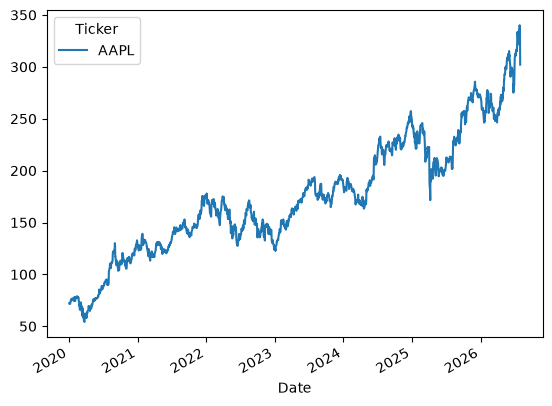

In [6]:
df['Close'].plot()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform((df['Close']))

In [8]:
seq_len=30
data=[]
for i in range(len(df)-seq_len):
    data.append(scaled_data[i:i+seq_len])

data=np.array(data)
data

array([[[-1.76374029],
        [-1.77584552],
        [-1.76602097],
        ...,
        [-1.68075164],
        [-1.64921176],
        [-1.65889382]],

       [[-1.77584552],
        [-1.76602097],
        [-1.77186609],
        ...,
        [-1.64921176],
        [-1.65889382],
        [-1.65856155]],

       [[-1.76602097],
        [-1.77186609],
        [-1.75196705],
        ...,
        [-1.65889382],
        [-1.65856155],
        [-1.68328605]],

       ...,

       [[ 2.09361559],
        [ 2.14215789],
        [ 2.08552512],
        ...,
        [ 2.72363735],
        [ 2.79059897],
        [ 2.84516618]],

       [[ 2.14215789],
        [ 2.08552512],
        [ 2.12098535],
        ...,
        [ 2.79059897],
        [ 2.84516618],
        [ 2.81263252]],

       [[ 2.08552512],
        [ 2.12098535],
        [ 2.10377163],
        ...,
        [ 2.84516618],
        [ 2.81263252],
        [ 2.73069504]]], shape=(1623, 30, 1))

In [18]:
train_size=int(0.8*len(data))
X_train=torch.from_numpy(data[:train_size,:-1,:]).type(torch.Tensor).to(device)
y_train=torch.from_numpy(data[:train_size,-1,:]).type(torch.Tensor).to(device)
X_test=torch.from_numpy(data[train_size:,:-1,:]).type(torch.Tensor).to(device)
y_test=torch.from_numpy(data[train_size:,-1,:]).type(torch.Tensor).to(device)

In [10]:
y_train

tensor([[-1.6589],
        [-1.6586],
        [-1.6833],
        ...,
        [ 0.3961],
        [ 0.2517],
        [ 0.3841]], device='cuda:0')

In [11]:
class PredictionModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_size,
        ##dropout
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
           ##dropout=dropout if num_layers > 1 else 0

        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
           ## nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.ReLU(),
           ## nn.Dropout(dropout),
            nn.Linear(hidden_size // 4, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        # Last timestep output
        out = out[:, -1, :]

        out = self.fc(out)

        return out

## Base Model

In [12]:
model=PredictionModel(input_size=1,hidden_size=32,num_layers=2,output_size=1).to(device)

In [21]:
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/astitvamishra0393/Stock_price_pred.mlflow")

In [13]:
import torch.optim as optim
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [14]:
epochs = 200

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    y_train_pred = model(X_train)

    loss = criterion(
        y_train_pred,
        y_train
    )

    loss.backward()

    optimizer.step()


    train_losses.append(loss.item())


    if epoch % 20 == 0:
        print(
            f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}"
        )

Epoch [0/200], Loss: 0.615050
Epoch [20/200], Loss: 0.102171
Epoch [40/200], Loss: 0.008954
Epoch [60/200], Loss: 0.004756
Epoch [80/200], Loss: 0.003793
Epoch [100/200], Loss: 0.003500
Epoch [120/200], Loss: 0.003277
Epoch [140/200], Loss: 0.003103
Epoch [160/200], Loss: 0.002955
Epoch [180/200], Loss: 0.002830


In [19]:
model.eval()

with torch.no_grad():

    y_test_pred = model(X_test)

    test_loss = criterion(
        y_test_pred,
        y_test
    )


print(f"Test Loss: {test_loss.item():.6f}")

Test Loss: 0.008940


In [20]:
y_train_pred=scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train=scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred=scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test=scaler.inverse_transform(y_test.detach().cpu().numpy())

AttributeError: 'numpy.ndarray' object has no attribute 'detach'